# Create scotus_scraped_data json file

The SCOTUS Scraped data is scraped by Normal and Application dockets, this notebook outlines the steps to look at some of the stats of the two different docket types and join into a larger scotus_scraped_data json file to be loaded into s3 & the db

# Import Libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the SCOTUS Scraped data

## Normal dockets

In [2]:
scotus_n = pd.read_json("data/scotus_data.json")
scotus_n.head()

,filename,docket_number,docket_date,case_title,lower_court,lower_court_case_numbers_raw,lower_court_case_numbers,lower_court_decision_date,lower_court_rehearing_denied_date,year,case_num
0,03-6084.htm,03-6084,2003-08-27,"Ronald Lee Smith, Petitioner v. Larry Reid, Wa...",United States Court of Appeals for the Tenth C...,(03-1016),03-1016,2003-05-16,2003-07-09,3,6084
1,03-10616.htm,03-10616,2004-05-28,"Jimmy Walker, Petitioner v. Florida","District Court of Appeal of Florida, Fourth Di...",(4D02-4272),4D02-4272,2004-04-21,None,3,10616
2,03-777.htm,03-777,2003-11-28,"Willie R. Flint, Petitioner v. ABB Inc., fka A...",United States Court of Appeals for the Elevent...,(02-15029),02-15029,2003-07-21,2003-08-27,3,777
3,03-10170.htm,03-10170,2004-05-05,"Loyda Lugones, Petitioner v. United States",United States Court of Appeals for the Elevent...,(02-12984),02-12984,2004-01-26,None,3,10170
4,03-8917.htm,03-8917,2004-02-19,"Ray Charles Smith, Petitioner v. United States",United States Court of Appeals for the Ninth C...,(03-10003),03-10003,2003-11-13,None,3,8917


## Look at some stats of Normal dockets

In [3]:
len(scotus_n)

165583

In [4]:
len(scotus_n[~scotus_n["lower_court"].isnull()])

160432

In [5]:
len(scotus_n[~scotus_n["lower_court_case_numbers"].isnull()])

160366

In [6]:
len(scotus_n[~scotus_n["lower_court_decision_date"].isnull()])

143778

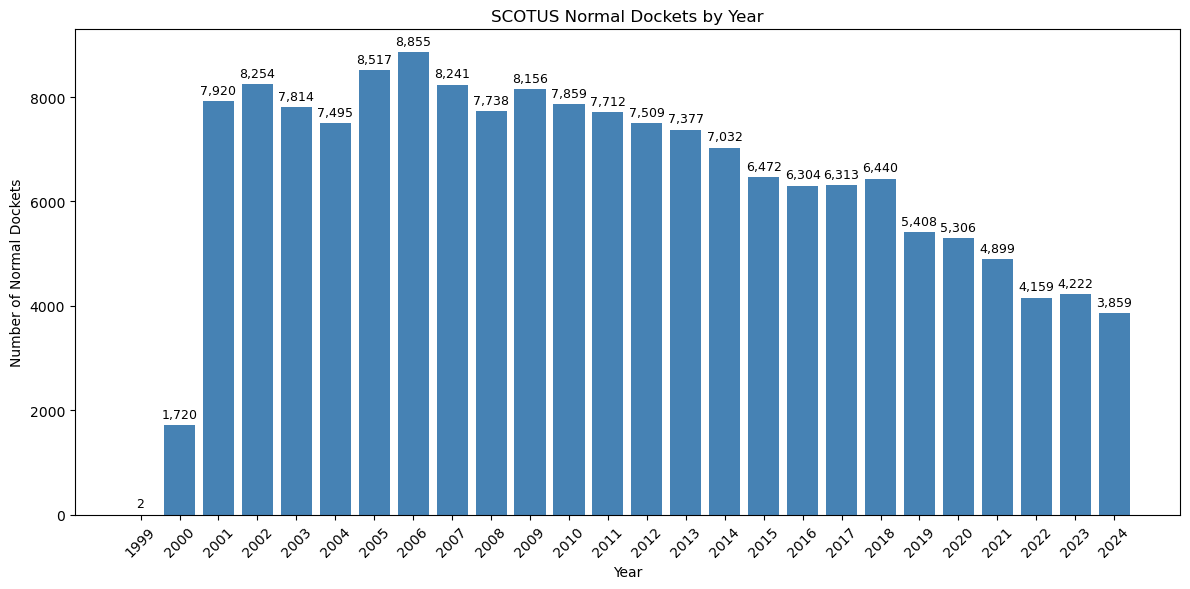

In [7]:
year_counts = scotus_n["year"].value_counts().sort_index()

# Convert 2-digit years to full years
def convert_year(y):
    return 1900 + y if y >= 90 else 2000 + y

full_years = year_counts.index.map(convert_year)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(full_years, year_counts.values, color="steelblue")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=9
    )

# Axis labels and title
ax.set_xlabel("Year")
ax.set_ylabel("Number of Normal Dockets")
ax.set_title("SCOTUS Normal Dockets by Year")
ax.set_xticks(full_years)
ax.set_xticklabels(full_years, rotation=45)

plt.tight_layout()
plt.show()

## Application dockets

In [8]:
scotus_a = pd.read_json("data/scotus_data_A.json")
scotus_a.head()

,filename,docket_number,docket_date,case_title,lower_court,lower_court_case_numbers_raw,lower_court_case_numbers,lower_court_decision_date,lower_court_rehearing_denied_date,year,case_num
0,03A517.htm,03A517,None,"Randy Kailey, Applicant v. Colorado",Court of Appeals of Colorado,"(01CA1378, 01CA2294)","01CA1378, 01CA2294",None,NaN,3,517
1,03A271.htm,03A271,None,"Christie M. Browne, Applicant v. John D. Ashcr...",United States Court of Appeals for the Fifth C...,(03-60138),03-60138,None,NaN,3,271
2,03A265.htm,03A265,None,"Dameon Sean White, Applicant v. California","Court of Appeal of California, Fifth Appellate...",(F039132),F039132,None,NaN,3,265
3,03A503.htm,03A503,None,"James E. Reid, Applicant v. Page True, Warden",United States Court of Appeals for the Fourth ...,"(02-27, 03-2)","02-27, 03-2",None,NaN,3,503
4,03A259.htm,03A259,None,"Stephan A. Bitterman, Individually, and as Per...",Supreme Court of Florida,(SC03-1059),SC03-1059,None,NaN,3,259


## Look at some stats of Application dockets

In [9]:
len(scotus_a)

25831

In [10]:
len(scotus_a[~scotus_a["lower_court"].isnull()])

25524

In [11]:
len(scotus_a[~scotus_a["lower_court_case_numbers"].isnull()])

25479

In [12]:
len(scotus_a[~scotus_a["lower_court_decision_date"].isnull()])

45

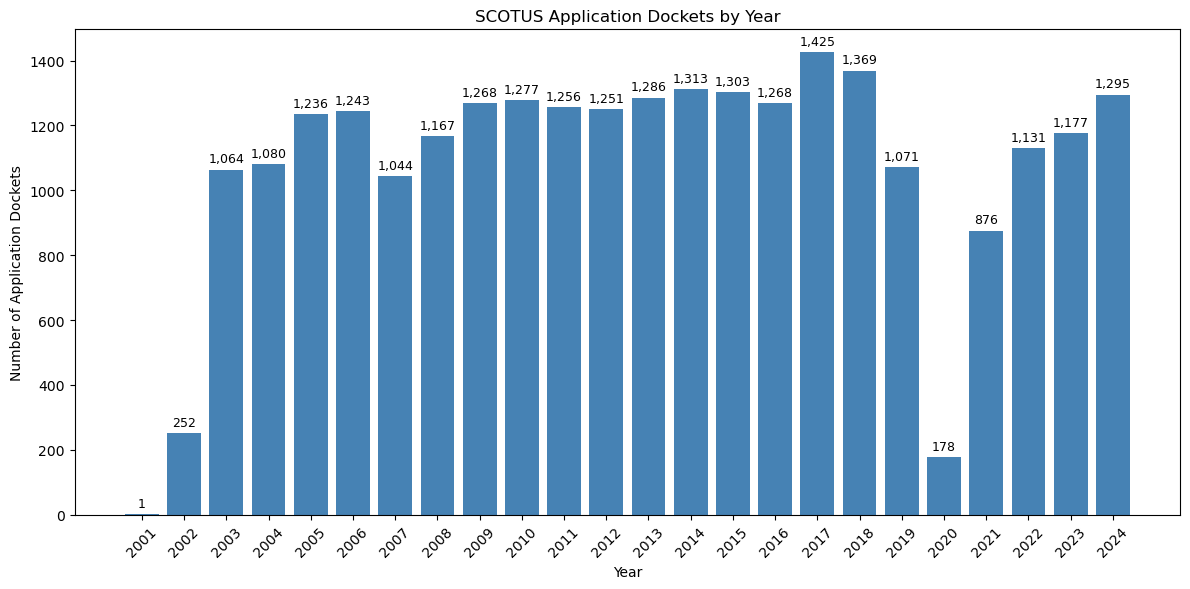

In [13]:
year_counts = scotus_a["year"].value_counts().sort_index()

# Convert 2-digit years to full years
def convert_year(y):
    return 1900 + y if y >= 90 else 2000 + y

full_years = year_counts.index.map(convert_year)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(full_years, year_counts.values, color="steelblue")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=9
    )

# Axis labels and title
ax.set_xlabel("Year")
ax.set_ylabel("Number of Application Dockets")
ax.set_title("SCOTUS Application Dockets by Year")
ax.set_xticks(full_years)
ax.set_xticklabels(full_years, rotation=45)

plt.tight_layout()
plt.show()

# Create a large scotus df with both normal and application dockets

In [14]:
scotus = pd.concat([scotus_n, scotus_a]).set_index("docket_number").reset_index()
len(scotus)

191414

In [15]:
scotus.head()

,docket_number,filename,docket_date,case_title,lower_court,lower_court_case_numbers_raw,lower_court_case_numbers,lower_court_decision_date,lower_court_rehearing_denied_date,year,case_num
0,03-6084,03-6084.htm,2003-08-27,"Ronald Lee Smith, Petitioner v. Larry Reid, Wa...",United States Court of Appeals for the Tenth C...,(03-1016),03-1016,2003-05-16,2003-07-09,3,6084
1,03-10616,03-10616.htm,2004-05-28,"Jimmy Walker, Petitioner v. Florida","District Court of Appeal of Florida, Fourth Di...",(4D02-4272),4D02-4272,2004-04-21,None,3,10616
2,03-777,03-777.htm,2003-11-28,"Willie R. Flint, Petitioner v. ABB Inc., fka A...",United States Court of Appeals for the Elevent...,(02-15029),02-15029,2003-07-21,2003-08-27,3,777
3,03-10170,03-10170.htm,2004-05-05,"Loyda Lugones, Petitioner v. United States",United States Court of Appeals for the Elevent...,(02-12984),02-12984,2004-01-26,None,3,10170
4,03-8917,03-8917.htm,2004-02-19,"Ray Charles Smith, Petitioner v. United States",United States Court of Appeals for the Ninth C...,(03-10003),03-10003,2003-11-13,None,3,8917


In [16]:
scotus.to_json("data/scotus_scraped_data.json")

In [17]:
cl = pd.read_json("data/cl_scotus_dockets.json")
cl.head()

,docket_id,docket_number,cluster_id,case_name,date_filed,precedential_status,num_authorities
0,7470,290,105849,Securities & Exchange Commission v. Variable A...,1959-03-23,Published,12
1,1269,79-168,110165,"Strycker's Bay Neighborhood Council, Inc. v. K...",1980-01-07,Published,10
2,8948,1047,97897,Detroit United Railway v. City of Detroit,1913-05-26,Published,5
3,9534,13-5380,2642828,Woodward v. Alabama,2013-11-18,Relating-to,15
4,5084,01-8966,119762,Truesdale v. United States,2002-04-15,Published,0


In [18]:
cl["cluster_id"].nunique()

499348

In [19]:
cl["docket_id"].nunique()

499155

In [20]:
len(cl)

499348

In [21]:
len(cl[cl["docket_number"].isnull()])

1042

In [22]:
len(cl[cl["docket_number"] == ""])

8501

In [23]:
cl = cl[~cl["docket_number"].isnull()]
cl = cl[cl["docket_number"] != ""]
len(cl)

489805

## Inspect and remove any records with not-Published precedential_status as they are not opinions with precedential value

In [24]:
cl["precedential_status"].value_counts()

precedential_status
Published      489297
Relating-to       493
In-chambers        15
Name: count, dtype: int64

## Inspect number of authorities for each opinion

Most opinions are simply the decision from the court on granting or denying the writ without any substance for precedential value

In [25]:
cl["num_authorities"].describe()

count    489805.000000
mean          0.933382
std           5.725849
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         295.000000
Name: num_authorities, dtype: float64

In [26]:
cl[cl["num_authorities"] == 0]

,docket_id,docket_number,cluster_id,case_name,date_filed,precedential_status,num_authorities
4,5084,01-8966,119762,Truesdale v. United States,2002-04-15,Published,0
7,21360,03-10692,142088,Miller v. United States,2005-01-24,Published,0
10,21957,72-535,108675,United States and Interstate Commerce Commissi...,1973-02-20,Published,0
16,18547,03-7914,136087,"Hoffman v. Jones, Warden",2004-04-26,Published,0
17,15540,02-6511,124689,Dean v. United States,2002-10-21,Published,0
...,...,...,...,...,...,...,...
499337,66728460,No. 19-7937.,9367073,Yaney v. Mason,2020-05-18,Published,0
499341,66728345,No. 19-7979.,9366958,Chadwick v. United States,2020-05-04,Published,0
499343,66728561,No. 19-1021.,9367174,Jessop v. City of Fresno,2020-05-18,Published,0
499346,66728638,No. 19-1238.,9367251,Watson v. McCarthy,2020-05-26,Published,0


In [27]:
cl[cl["num_authorities"] > 0]["num_authorities"].describe()

count    59127.000000
mean         7.732085
std         14.799566
min          1.000000
25%          1.000000
50%          1.000000
75%          8.000000
max        295.000000
Name: num_authorities, dtype: float64

In [28]:
cl["cleaned_docket_number"] = cl["docket_number"].apply(clean_docket_numbers)

NameError: name 'clean_docket_numbers' is not defined

In [ ]:
cl_exploded = cl.explode("cleaned_docket_number", ignore_index=True)
cl_exploded.head()

In [ ]:
len(cl_exploded)

In [ ]:
cl_exploded["cleaned_docket_number"].nunique()

In [ ]:
cl_exploded["docket_type"] = cl_exploded["cleaned_docket_number"].apply(get_docket_type)

In [ ]:
cl_exploded[["cleaned_docket_number", "docket_type"]].drop_duplicates()["docket_type"].value_counts()

In [ ]:
cl_subset = cl_exploded[cl_exploded["docket_type"].isin(["N", "A"])].copy()

# Use regex to extract the year based on docket type
cl_subset["year"] = np.select(
    [
        cl_subset["docket_type"] == "N",
        cl_subset["docket_type"] == "A",
    ],
    [
        # Extract digits before hyphen (e.g., "21-123" → "21")
        cl_subset["cleaned_docket_number"].str.extract(r"^(\d+)-")[0],
        # Extract digits before 'A' (e.g., "22A456" → "22")
        cl_subset["cleaned_docket_number"].str.extract(r"^(\d+)A")[0],
    ],
    default=np.nan
)

# Convert to Int64, allowing for blanks (NaN)
cl_subset["year"] = pd.to_numeric(cl_subset["year"], errors="coerce").astype("Int64")

cl_subset.head()

## Sanity check for dockets that exist in CL but not in SCOTUS scraped data

- There are generally a lot more data in CL because of duplicates and the possibilities that one docket number could have multiple opinions.
- There are many missing dockets for year 1999 and 2000, this is because SCOTUS data become available beginning 2000, but not all the data are available from the website.
- For remaining years, I picked a few for sanity check and confirmed these are dockets that cannot be found from the SCOTUS docket search, these will need to be analyzed through parsing.

In [ ]:
missing_dockets = {}
valid_dockets = {}

for docket_type in ["N", "A"]:
    print("*****", docket_type, "*****")
    cl_subset_subset = cl_subset[cl_subset["docket_type"] == docket_type]
    missing_dockets[docket_type] = {}
    valid_dockets[docket_type] = {}
    
    for yr in list(range(0, 25)) + [99]:
        print("---", yr, "---")
        
        cl_yr = cl_subset_subset[cl_subset_subset["year"] == yr]
        print("num_cl: ", len(cl_yr))
        
        scotus_yr = scotus[scotus["year"] == yr]
        print("num_scotus: ", len(scotus_yr))
    
        missing_dockets[docket_type][yr] = list(set(cl_yr["cleaned_docket_number"].to_list()) - set(scotus_yr["docket_number"].to_list()))
        valid_dockets[docket_type][yr] = cl_yr[cl_yr["cleaned_docket_number"].isin(scotus_yr["docket_number"].to_list())]["cleaned_docket_number"].to_list()
        
        print("docket nums in cl not in scotus: ", len(missing_dockets[docket_type][yr]))
        print("docket nums in cl and in scotus: ", len(valid_dockets[docket_type][yr]))

    print("==========================================================")
    print(f"number of dockets from {docket_type} dockets: ", len(set(cl_subset_subset["cleaned_docket_number"].to_list())))
    print(f"number of dockets from {docket_type} dockets in valid years: ", len([item for sublist in valid_dockets[docket_type].values() for item in sublist]) + len([item for sublist in missing_dockets[docket_type].values() for item in sublist]))
    print(f"number of valid dockets from {docket_type} dockets: ", len([item for sublist in valid_dockets[docket_type].values() for item in sublist]))
    print(f"number of missing dockets from {docket_type} dockets: ", len([item for sublist in missing_dockets[docket_type].values() for item in sublist]))

In [ ]:
for key, val in missing_dockets["N"].items():
    print("year: ", key, "num missing: ", len(val))

In [ ]:
for key, val in missing_dockets["A"].items():
    print("year: ", key, "num missing: ", len(val))

## Join the scotus scraped normal dockets to cl dockets 
1. on docket number
2. cl date_filed must be within 1-year of scotus docket_date

In [ ]:
scotus['docket_date'] = pd.to_datetime(scotus['docket_date'])
cl_subset['date_filed'] = pd.to_datetime(cl_subset['date_filed'])

merged = pd.merge(cl_subset, scotus, left_on='cleaned_docket_number', right_on='docket_number', how='left')

# Filter for date_filed within 1 year of docket_date
# i.e., docket_date - 365 <= date_filed <= docket_date + 365
mask = (merged['date_filed'] >= merged['docket_date'] - pd.Timedelta(days=365*2)) & \
       (merged['date_filed'] <= merged['docket_date'] + pd.Timedelta(days=365*2))

result = merged[mask]
result

In [ ]:
result["cleaned_docket_number"].nunique()

In [ ]:
joineable_dockets = list(result["cleaned_docket_number"].unique())
cl_exploded[cl_exploded["cleaned_docket_number"].isin(joineable_dockets)]["cluster_id"].nunique()

In [ ]:
valid_docket_nums = [
    item
    for inner_dict in valid_dockets.values()
    for sublist in inner_dict.values()
    for item in sublist
]
len(valid_docket_nums)

In [ ]:
assert len(set(result["cleaned_docket_number"].to_list()) - set(valid_docket_nums)) == 0

In [ ]:
set(valid_docket_nums) - set(result["cleaned_docket_number"].to_list())

In [ ]:
len(set(valid_docket_nums) - set(result["cleaned_docket_number"].to_list()))

In [ ]:
merged[merged["cleaned_docket_number"] == "00-1295"]

In [ ]:
merged[merged["cleaned_docket_number"] == "22-63"]

In [ ]:
merged[merged["cleaned_docket_number"] == "22-24"]

In [ ]:
merged[merged["cleaned_docket_number"] == "20A136"]